In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import random

In [2]:
DATASET_PATH = Path("../dataset/tomato_yolo_dataset")

IMAGE_TRAIN = DATASET_PATH / "images" / "train"
IMAGE_VAL = DATASET_PATH / "images" / "val"

LABEL_TRAIN = DATASET_PATH / "labels" / "train"
LABEL_VAL = DATASET_PATH / "labels" / "val"

print("Dataset exists:", DATASET_PATH.exists())
print("Train images:", IMAGE_TRAIN.exists())
print("Validation images:", IMAGE_VAL.exists())
print("Train labels:", LABEL_TRAIN.exists())
print("Validation labels:", LABEL_VAL.exists())

Dataset exists: True
Train images: True
Validation images: True
Train labels: True
Validation labels: True


In [3]:
train_images = list(IMAGE_TRAIN.glob("*"))
val_images = list(IMAGE_VAL.glob("*"))

print("Training images:", len(train_images))
print("Validation images:", len(val_images))

Training images: 14526
Validation images: 3632


In [4]:
class_ids = Counter()

for label_file in LABEL_TRAIN.glob("*.txt"):
    with open(label_file, "r") as f:
        for line in f:
            values = line.strip().split()

            if len(values) == 5:
                class_id = int(values[0])
                class_ids[class_id] += 1

print(class_ids)

Counter({7: 4277, 0: 1700, 2: 1531, 4: 1431, 5: 1356, 9: 1286, 6: 1113, 1: 785, 3: 761, 8: 301})


In [5]:
class_names = {
    0: "Bacterial spot",
    1: "Early blight",
    2: "Late blight",
    3: "Leaf Mold",
    4: "Septoria leaf spot",
    5: "Spider mites",
    6: "Target Spot",
    7: "Tomato Yellow Leaf Curl Virus",
    8: "Tomato mosaic virus",
    9: "Healthy"
}

for class_id, count in sorted(class_ids.items()):
    print(class_id, "→", class_names.get(class_id, "Unknown"), ":", count)

0 → Bacterial spot : 1700
1 → Early blight : 785
2 → Late blight : 1531
3 → Leaf Mold : 761
4 → Septoria leaf spot : 1431
5 → Spider mites : 1356
6 → Target Spot : 1113
7 → Tomato Yellow Leaf Curl Virus : 4277
8 → Tomato mosaic virus : 301
9 → Healthy : 1286


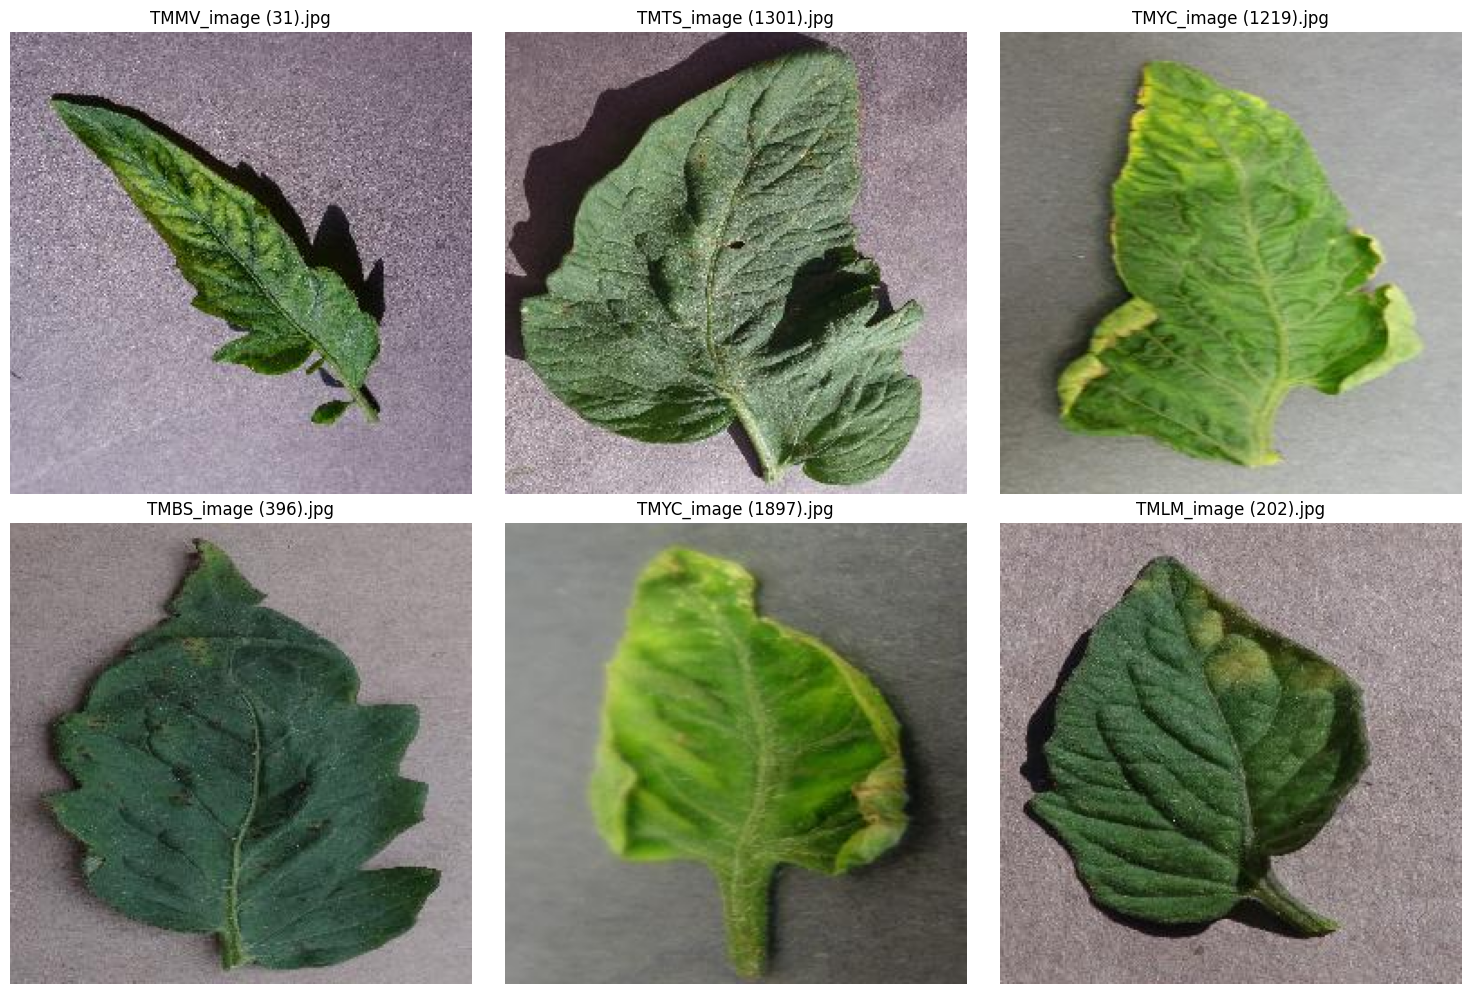

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Pick 6 random training images
sample_images = random.sample(train_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, image_path in zip(axes.ravel(), sample_images):
    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

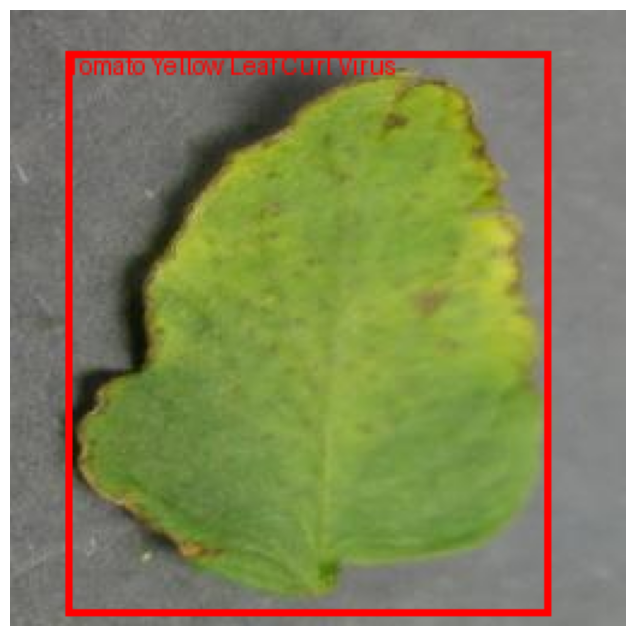

In [8]:
from PIL import ImageDraw

# Take one random image
image_path = random.choice(train_images)

# Open image
image = Image.open(image_path).convert("RGB")
draw = ImageDraw.Draw(image)

# Corresponding label file
label_path = LABEL_TRAIN / (image_path.stem + ".txt")

# Image dimensions
img_width, img_height = image.size

# Read YOLO labels
with open(label_path, "r") as f:
    for line in f:
        values = line.strip().split()

        if len(values) != 5:
            continue

        class_id, x_center, y_center, width, height = map(float, values)

        # Convert YOLO coordinates to pixel coordinates
        x_center *= img_width
        y_center *= img_height
        width *= img_width
        height *= img_height

        x1 = int(x_center - width / 2)
        y1 = int(y_center - height / 2)
        x2 = int(x_center + width / 2)
        y2 = int(y_center + height / 2)

        # Draw box
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

        # Class name
        label = class_names[int(class_id)]

        draw.text((x1, y1), label, fill="red")

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [9]:
object_counts = []

for label_file in LABEL_TRAIN.glob("*.txt"):
    with open(label_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    object_counts.append(len(lines))

print("Total labeled images:", len(object_counts))
print("Images with 1 object:", object_counts.count(1))
print("Images with 2 objects:", object_counts.count(2))
print("Images with 3 objects:", object_counts.count(3))
print("Images with more than 3 objects:",
      sum(1 for x in object_counts if x > 3))

Total labeled images: 14526
Images with 1 object: 14512
Images with 2 objects: 13
Images with 3 objects: 1
Images with more than 3 objects: 0


In [10]:
from collections import Counter

image_sizes = Counter()

for image_path in train_images:
    try:
        with Image.open(image_path) as img:
            image_sizes[img.size] += 1
    except:
        pass

print("Number of different image sizes:", len(image_sizes))

print("\nMost common image sizes:")
for size, count in image_sizes.most_common(10):
    print(size, "→", count)

Number of different image sizes: 1

Most common image sizes:
(256, 256) → 14526


In [11]:
box_areas = []

for label_file in LABEL_TRAIN.glob("*.txt"):
    with open(label_file, "r") as f:
        for line in f:
            values = line.strip().split()

            if len(values) != 5:
                continue

            _, _, _, width, height = map(float, values)

            # YOLO width and height are fractions of the image
            area = width * height
            box_areas.append(area)

print("Number of bounding boxes:", len(box_areas))
print("Average box area:", sum(box_areas) / len(box_areas))
print("Smallest box area:", min(box_areas))
print("Largest box area:", max(box_areas))

Number of bounding boxes: 14541
Average box area: 0.750751004755748
Smallest box area: 0.037292531250000004
Largest box area: 1.0
